In [22]:
import ase
import ase.io
from ase.visualize import view


In [23]:
dimer = ase.io.read("/mmhome/boittier/home/mmml_tutorial/cli_water/out/tip3_dimers_test.xyz", index=0)
monomer = ase.io.read("/mmhome/boittier/home/mmml_tutorial/cli_water/pdb/initial.pdb")


In [24]:
view(dimer, viewer="x3d")

In [25]:
view(monomer, viewer="x3d")

Interaction energy:  -0.14612674713134766 eV
Charges [array([-0.48869562,  0.26841038,  0.32182398, -0.534772  ,  0.25778177,
        0.24201342], dtype=float32), array([-0.5727372 ,  0.30085725,  0.31005204], dtype=float32), array([-0.5733605 ,  0.29769883,  0.2998185 ], dtype=float32)]


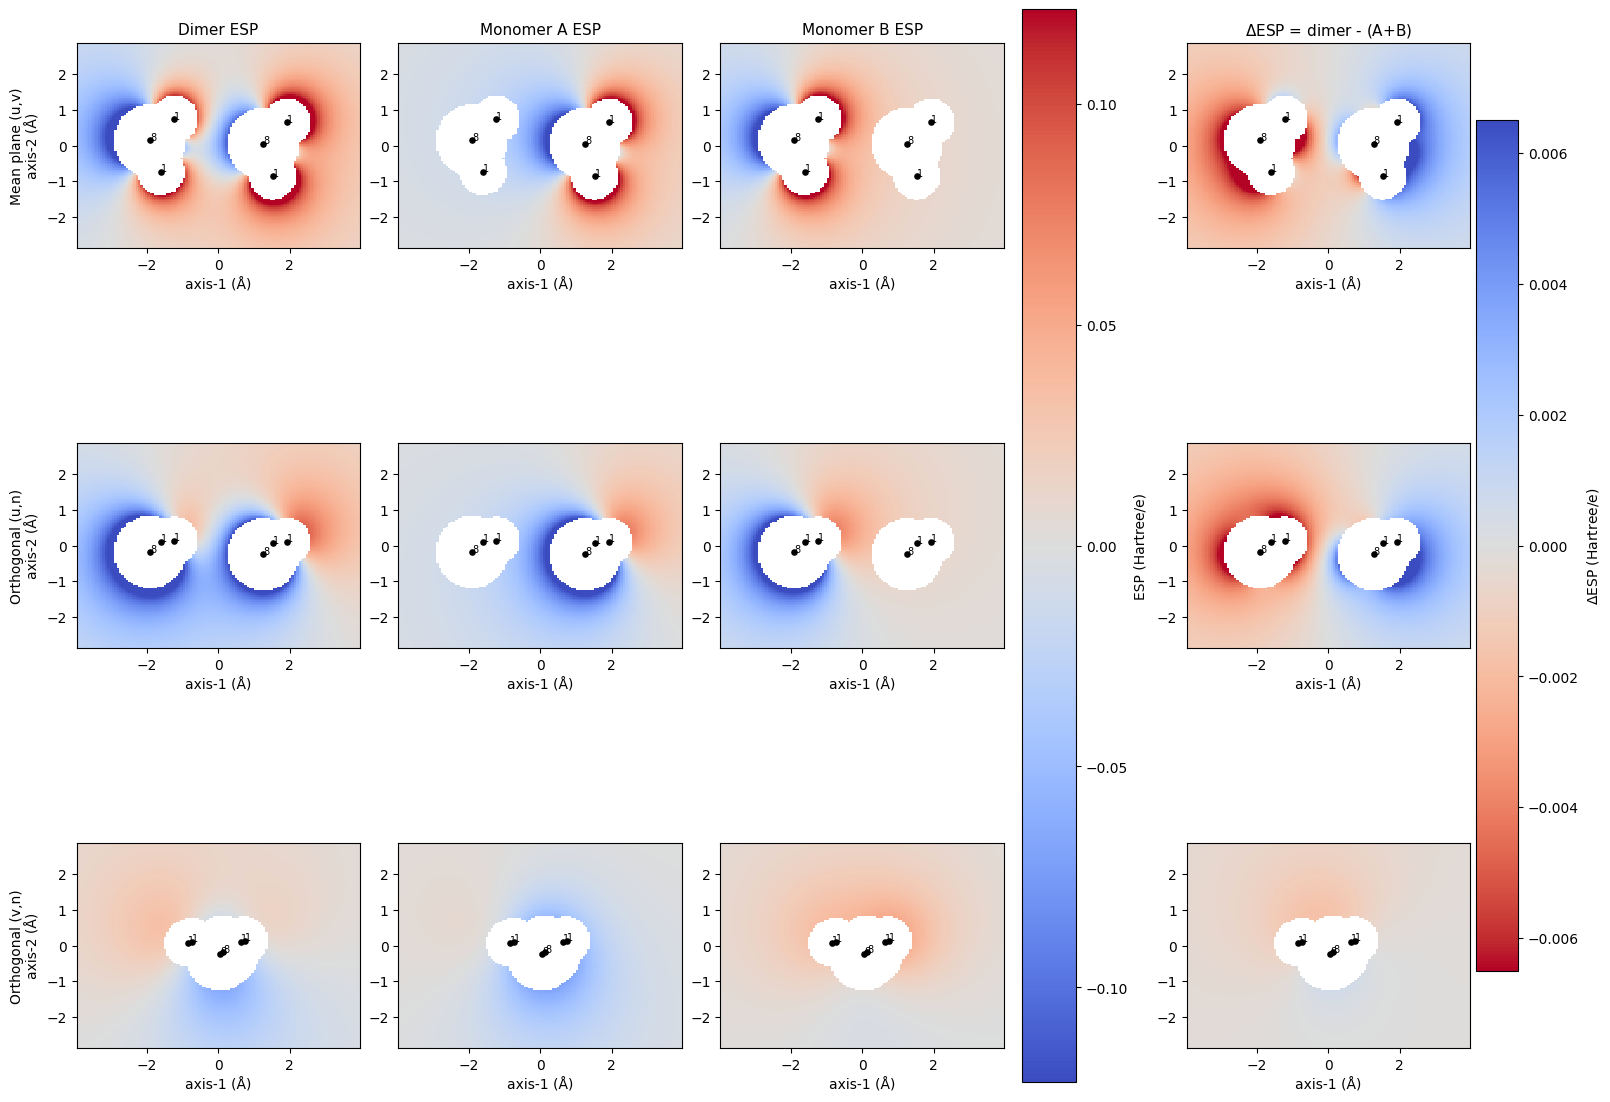

In [49]:
dimer = ase.io.read("/mmhome/boittier/home/mmml_tutorial/cli_water/out/tip3_dimers_test.xyz", index=0)
monomer = ase.io.read("/mmhome/boittier/home/mmml_tutorial/cli_water/pdb/initial.pdb")


monomer_A = dimer[:3]
monomer_B = dimer[3:]



SOURCE = "dcmnet"

import mmml
from mmml.interfaces.calculators.simple_inference import create_calculator_from_checkpoint

# calc = create_calculator_from_checkpoint("/mmhome/boittier/home/ckpts/water_mono_dimer_md_joint_ndc2_zbl_2/best_params.pkl")
calc = create_calculator_from_checkpoint("/mmhome/boittier/home/ckpts/water_mono_dimer_md_joint_ndc2_zbl_mix/best_params.pkl")

calc.use_dcmnet_dipole = True

energies = []
charges = []
for atoms in [dimer, monomer_A, monomer_B]:
    atoms.calc = calc
    
    E = atoms.get_potential_energy()
    F = atoms.get_forces()
    energies.append(E)
    
    q = atoms.get_charges()
    mu = atoms.get_dipole_moment()
    charges.append(q)
    # print(E, F, q, mu)


intE = energies[0] - energies[1] - energies[2]

print("Interaction energy: ", intE, "eV")
print("Charges", charges)

atoms = dimer



%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from ase.data import covalent_radii

# =========================
# Inputs you must already have:
#   calc       : SimpleInferenceCalculator (or compatible)
#   atoms      : dimer ASE Atoms (reference geometry/frame)
#   monomer_A  : ASE Atoms in SAME coordinate frame
#   monomer_B  : ASE Atoms in SAME coordinate frame
# =========================

def esp_on_fixed_grid(calc, atoms_obj, grid_flat, source="dcmnet"):
    atoms_obj.calc = calc
    _ = atoms_obj.get_potential_energy()  # refresh calculator cache
    return calc.get_electrostatic_potential(grid_flat, source=source)

def build_mask_from_dimer(grid_flat, dimer_atoms, buffer=0.35):
    R = dimer_atoms.get_positions()
    Z = dimer_atoms.get_atomic_numbers()
    r_excl = covalent_radii[Z] + buffer
    d = np.linalg.norm(grid_flat[:, None, :] - R[None, :, :], axis=-1)  # (n_grid, n_atoms)
    keep = (d >= r_excl[None, :]).all(axis=1)
    return keep

def build_inplane_mask(XX, YY, xproj, yproj, atom_numbers, buffer=0.35):
    """
    XX, YY: 2D plane coordinates (ny, nx)
    xproj, yproj: projected dimer atom coordinates onto this plane (n_atoms,)
    atom_numbers: dimer atomic numbers (n_atoms,)
    """
    r_excl = covalent_radii[atom_numbers] + buffer  # (n_atoms,)
    # distances in plane from each grid point to each projected atom
    dx = XX[..., None] - xproj[None, None, :]   # (ny, nx, n_atoms)
    dy = YY[..., None] - yproj[None, None, :]
    d2d = np.sqrt(dx**2 + dy**2)
    keep2d = (d2d >= r_excl[None, None, :]).all(axis=-1)  # (ny, nx)
    return keep2d

# ---------- 1) Reference frame + principal axes from dimer ----------
dimer = atoms
R = dimer.get_positions()
Z = dimer.get_atomic_numbers()

center = R.mean(axis=0)
X = R - center
_, _, vh = np.linalg.svd(X, full_matrices=False)
u, v, n = vh[0], vh[1], vh[2]  # orthonormal axes

planes = [
    ("Mean plane (u,v)", u, v),
    ("Orthogonal (u,n)", u, n),
    ("Orthogonal (v,n)", v, n),
]

# ---------- 2) Shared global bounds across ALL planes ----------
proj = []
for title, a, b in planes:
    xa = (R - center) @ a
    yb = (R - center) @ b
    proj.append((title, a, b, xa, yb))

pad = 2.0
all_x = np.concatenate([p[3] for p in proj])
all_y = np.concatenate([p[4] for p in proj])

xmax_abs = max(abs(all_x.min()), abs(all_x.max())) + pad
ymax_abs = max(abs(all_y.min()), abs(all_y.max())) + pad

xmin, xmax = -xmax_abs, xmax_abs
ymin, ymax = -ymax_abs, ymax_abs

nx, ny = 120, 120
gx = np.linspace(xmin, xmax, nx)
gy = np.linspace(ymin, ymax, ny)
XX, YY = np.meshgrid(gx, gy, indexing="xy")

# ---------- 3) Compute ESP maps on identical grids ----------
maps = []
for title, a, b, xproj, yproj in proj:
    # Same in-plane coordinates XX,YY for each plane, mapped to 3D via (a,b)
    grid3d = center + XX[..., None] * a + YY[..., None] * b
    grid_flat = grid3d.reshape(-1, 3)

    esp_dimer = esp_on_fixed_grid(calc, dimer, grid_flat, source=SOURCE)
    esp_A     = esp_on_fixed_grid(calc, monomer_A, grid_flat, source=SOURCE)
    esp_B     = esp_on_fixed_grid(calc, monomer_B, grid_flat, source=SOURCE)
    esp_diff  = esp_dimer - (esp_A + esp_B)

    keep2d = build_inplane_mask(XX, YY, xproj, yproj, Z, buffer=0.35)
    def as2d_masked(arr):
        arr2 = arr.reshape(ny, nx).copy()
        arr2[~keep2d] = np.nan
        return arr2

    maps.append({
        "title": title,
        "xproj": xproj,
        "yproj": yproj,
        "dimer": as2d_masked(esp_dimer),
        "A": as2d_masked(esp_A),
        "B": as2d_masked(esp_B),
        "diff": as2d_masked(esp_diff),
    })

# ---------- 4) Shared color limits ----------
esp_vals = np.concatenate([
    m["dimer"][np.isfinite(m["dimer"])].ravel() for m in maps
] + [
    m["A"][np.isfinite(m["A"])].ravel() for m in maps
] + [
    m["B"][np.isfinite(m["B"])].ravel() for m in maps
])

diff_vals = np.concatenate([
    m["diff"][np.isfinite(m["diff"])].ravel() for m in maps
])

# robust symmetric scales
esp_lim = np.nanpercentile(np.abs(esp_vals), 99)
diff_lim = np.nanpercentile(np.abs(diff_vals), 99)

# ---------- 5) Plot 3x4 with two shared colorbars ----------
fig, axes = plt.subplots(3, 4, figsize=(16, 12), constrained_layout=True)

im_esp = None
im_diff = None

col_titles = ["Dimer ESP", "Monomer A ESP", "Monomer B ESP", r"$\Delta$ESP = dimer - (A+B)"]

for i, m in enumerate(maps):
    fields = ["dimer", "A", "B", "diff"]

    for j, key in enumerate(fields):
        ax = axes[i, j]
        cmap = "coolwarm" if key != "diff" else "coolwarm_r"
        vlim = esp_lim if key != "diff" else diff_lim

        im = ax.pcolormesh(XX, YY, m[key], shading="auto", cmap=cmap, vmin=-vlim, vmax=vlim)

        if key != "diff" and im_esp is None:
            im_esp = im
        if key == "diff" and im_diff is None:
            im_diff = im

        # dimer atoms projected into current plane for reference
        ax.scatter(m["xproj"], m["yproj"], c="k", s=14)
        for k, z in enumerate(Z):
            ax.text(m["xproj"][k], m["yproj"][k], str(int(z)), color="k", fontsize=7)

        if i == 0:
            ax.set_title(col_titles[j], fontsize=11)
        if j == 0:
            ax.set_ylabel(f"{m['title']}\naxis-2 (Å)")
        ax.set_xlabel("axis-1 (Å)")
        ax.set_aspect("equal", adjustable="box")

# shared colorbar for ESP columns 1-3
cbar1 = fig.colorbar(im_esp, ax=axes[:, :3].ravel().tolist(), shrink=0.9, pad=0.02)
cbar1.set_label("ESP (Hartree/e)")

# shared colorbar for DeltaESP column 4
cbar2 = fig.colorbar(im_diff, ax=axes[:, 3].ravel().tolist(), shrink=0.9, pad=0.02)
cbar2.set_label(r"$\Delta$ESP (Hartree/e)")
plt.savefig("esp_difference_c.png", bbox_inches="tight")
plt.show()

In [28]:
# dir(atoms.calc)
DCMs = dimer.calc.get_distributed_multipoles()

DCMs

{'monopoles': array([[-0.4216418 ,  0.2439445 ],
        [-0.6495183 ,  0.7399502 ],
        [-0.64451003,  0.7348757 ]], dtype=float32),
 'dipole_positions': array([[[-0.31449947,  1.5533284 ,  2.6535985 ],
         [-0.5262849 ,  1.6367027 ,  2.8953297 ]],
 
        [[-0.31334114,  1.5530536 ,  2.6522298 ],
         [-0.11893542,  0.8825458 ,  2.585681  ]],
 
        [[-0.31343827,  1.5517235 ,  2.6524196 ],
         [-0.07133569,  2.0569923 ,  2.2194629 ]]], dtype=float32),
 'atomic_charges': array([-0.1776973 ,  0.09043187,  0.09036565], dtype=float32)}

In [29]:
calc.model

JointPhysNetDCMNet(
    # attributes
    physnet_config = {'features': 64, 'max_degree': 0, 'num_iterations': 2, 'num_basis_functions': 64, 'cutoff': 6.0, 'max_atomic_number': 28, 'charges': True, 'natoms': 6, 'total_charge': 0.0, 'n_res': 3, 'zbl': True, 'use_energy_bias': True, 'debug': False, 'efa': False, 'include_electrostatics': False}
    dcmnet_config = {'features': 128, 'max_degree': 2, 'num_iterations': 2, 'num_basis_functions': 64, 'cutoff': 10.0, 'max_atomic_number': 28, 'n_dcm': 2, 'include_pseudotensors': False}
    mix_coulomb_energy = False
    mixer_config = None
)

In [30]:
atoms.get_positions()

array([[-4.36679400e-02, -1.82744000e-03,  3.27289400e-02],
       [ 3.38395690e-01, -8.61357430e-01, -1.66571460e-01],
       [ 3.79459910e-01,  6.27514230e-01, -6.08494930e-01],
       [-4.06236340e-01,  1.58874074e+00,  2.75850976e+00],
       [-5.25938800e-02,  7.18639370e-01,  2.54599317e+00],
       [ 5.60990000e-03,  2.16427735e+00,  2.09570590e+00]])

In [31]:
view(atoms, viewer="x3d")

In [32]:
DCMs["dipole_positions"][0] - atoms.get_positions()[:2]

array([[-0.27083153,  1.55515583,  2.62086961],
       [-0.86468056,  2.49806009,  3.06190117]])

In [33]:
DCMs["dipole_positions"][1] - atoms.get_positions()[2:4]

array([[-0.69280105,  0.92553939,  3.26072472],
       [ 0.28730092, -0.70619491, -0.1728288 ]])

In [34]:
DCMs["dipole_positions"][2] - atoms.get_positions()[4:]

array([[-0.26084439,  0.83308411,  0.1064264 ],
       [-0.07694559, -0.10728506,  0.12375697]])

In [35]:
import jax
jax.devices()

[CudaDevice(id=0)]

In [36]:
dimer

Atoms(symbols='OH2OH2', pbc=False, calculator=SimpleInferenceCalculator(...))

In [38]:
view(dimer, viewer="x3d")

In [44]:
# --- Setup ---
from ase import Atoms, units
from ase.optimize import BFGS
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation
from mmml.interfaces.calculators.simple_inference import create_calculator_from_checkpoint
import mmml
from mmml.interfaces.calculators.simple_inference import create_calculator_from_checkpoint

calc = create_calculator_from_checkpoint("/mmhome/boittier/home/ckpts/water_mono_dimer_md_joint_ndc2_zbl_mix/best_params.pkl")


INDEX = 1

calc.use_dcmnet_dipole = True
dimer = ase.io.read("/mmhome/boittier/home/mmml_tutorial/cli_water/out/tip3_dimers_test.xyz", index=INDEX)
atoms = dimer
atoms.calc = calc

# --- BFGS geometry optimization ---
opt = BFGS(atoms, 
           # trajectory="opt.traj", logfile="opt.log"
          )
opt.run(fmax=0.2, steps=50)  # eV/Å

print("Optimized energy (eV):", atoms.get_potential_energy())
print("Max force (eV/Å):", abs(atoms.get_forces()).max())

      Step     Time          Energy          fmax
BFGS:    0 17:30:15      -19.833759        0.628939
BFGS:    1 17:30:15      -19.836561        0.342001
BFGS:    2 17:30:16      -19.837994        0.165013
Optimized energy (eV): -19.837993621826172
Max force (eV/Å): 0.12218065


In [45]:
dir(calc)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_deprecated',
 '_deprecated_get_spin_polarized',
 '_directory',
 '_get_name',
 '_last_atomic_numbers',
 '_last_dipole_positions',
 '_last_monopoles',
 '_last_positions',
 'atoms',
 'band_structure',
 'calculate',
 'calculate_numerical_forces',
 'calculate_numerical_stress',
 'calculate_properties',
 'calculation_required',
 'check_state',
 'cutoff',
 'default_parameters',
 'directory',
 'discard_results_on_any_change',
 'export_properties',
 'get_atoms',
 'get_charges',
 'get_default_para

In [46]:
calc.model

JointPhysNetDCMNet(
    # attributes
    physnet_config = {'features': 64, 'max_degree': 0, 'num_iterations': 2, 'num_basis_functions': 64, 'cutoff': 6.0, 'max_atomic_number': 28, 'charges': True, 'natoms': 6, 'total_charge': 0.0, 'n_res': 3, 'zbl': True, 'use_energy_bias': True, 'debug': False, 'efa': False, 'include_electrostatics': False}
    dcmnet_config = {'features': 128, 'max_degree': 2, 'num_iterations': 2, 'num_basis_functions': 64, 'cutoff': 10.0, 'max_atomic_number': 28, 'n_dcm': 2, 'include_pseudotensors': False}
    mix_coulomb_energy = False
    mixer_config = None
)

In [47]:
view(atoms, viewer="x3d")

In [48]:
# --- NVE molecular dynamics (VelocityVerlet) ---
# (usually start from optimized geometry)

# Optional: save MD trajectory
from ase.io.trajectory import Trajectory
traj = Trajectory(f"nve{INDEX}.traj", "w", atoms)



MaxwellBoltzmannDistribution(atoms, temperature_K=300.0)
Stationary(atoms)      # remove net translation
ZeroRotation(atoms)    # remove net rotation

dyn = VelocityVerlet(atoms, timestep=0.25 * units.fs)  # 0.05 fs
dyn.attach(traj.write, interval=10)

def log_md():
    epot = atoms.get_potential_energy()
    ekin = atoms.get_kinetic_energy()
    temp = atoms.get_temperature()
    print(f"Epot={epot: .6f} eV  Ekin={ekin: .6f} eV  Etot={epot+ekin: .6f} eV  T={temp: .1f} K")

dyn.attach(log_md, interval=10)
dyn.run(200)  # number of MD steps

Epot=-19.837994 eV  Ekin= 0.148031 eV  Etot=-19.689963 eV  T= 190.9 K
Epot=-19.782337 eV  Ekin= 0.092304 eV  Etot=-19.690033 eV  T= 119.0 K
Epot=-19.801065 eV  Ekin= 0.111873 eV  Etot=-19.689192 eV  T= 144.2 K
Epot=-19.808094 eV  Ekin= 0.116823 eV  Etot=-19.691271 eV  T= 150.6 K
Epot=-19.820381 eV  Ekin= 0.129456 eV  Etot=-19.690925 eV  T= 166.9 K
Epot=-19.840742 eV  Ekin= 0.150333 eV  Etot=-19.690409 eV  T= 193.8 K
Epot=-19.795860 eV  Ekin= 0.105068 eV  Etot=-19.690792 eV  T= 135.5 K
Epot=-19.844908 eV  Ekin= 0.155579 eV  Etot=-19.689329 eV  T= 200.6 K
Epot=-19.852089 eV  Ekin= 0.161417 eV  Etot=-19.690672 eV  T= 208.1 K
Epot=-19.870157 eV  Ekin= 0.180256 eV  Etot=-19.689901 eV  T= 232.4 K
Epot=-19.882689 eV  Ekin= 0.192055 eV  Etot=-19.690633 eV  T= 247.6 K
Epot=-19.871866 eV  Ekin= 0.182702 eV  Etot=-19.689164 eV  T= 235.6 K



KeyboardInterrupt



In [375]:
view(atoms, viewer="x3d")

In [376]:
# --- BFGS geometry optimization ---
opt = BFGS(atoms, 
           # trajectory="opt.traj", logfile="opt.log"
          )
opt.run(fmax=0.2, steps=20)  # eV/Å

print("Optimized energy (eV):", atoms.get_potential_energy())
print("Max force (eV/Å):", abs(atoms.get_forces()).max())

      Step     Time          Energy          fmax
BFGS:    0 12:53:32      -20.074688        1.649708
BFGS:    1 12:53:33      -20.088881        1.215985
BFGS:    2 12:53:34      -20.101351        0.241110
BFGS:    3 12:53:34      -20.102724        0.234729
BFGS:    4 12:53:35      -20.109468        0.331833
BFGS:    5 12:53:36      -20.115223        0.339280
BFGS:    6 12:53:37      -20.123741        0.504250
BFGS:    7 12:53:37      -20.133160        0.663069
BFGS:    8 12:53:38      -20.146511        0.530023
BFGS:    9 12:53:39      -20.155882        0.350723
BFGS:   10 12:53:40      -20.157194        0.418281
BFGS:   11 12:53:40      -20.158722        0.194427
Optimized energy (eV): -20.158721923828125
Max force (eV/Å): 0.18912561


In [377]:
view(atoms, viewer="x3d")

In [378]:
import numpy as np
d=np.load("out/splits_mono_dimer/energies_forces_dipoles_train.npz")
R,N=d["R"],d["N"]
print("NaN R/E/F:", np.isnan(d["R"]).any(), np.isnan(d["E"]).any(), np.isnan(d["F"]).any())
mins=[]
for i in range(len(N)):
    n=int(N[i]); r=R[i,:n]
    if n<2: continue
    D=np.linalg.norm(r[:,None,:]-r[None,:,:],axis=-1)
    D[D==0]=1e9
    mins.append(D.min())
print("global min pair distance:", np.min(mins))

NaN R/E/F: False False False
global min pair distance: 0.7404478758458781
